In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_csv("Titanic_Train.csv")

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [92]:
df['Age']=df['Age'].fillna(df['Age'].mean())

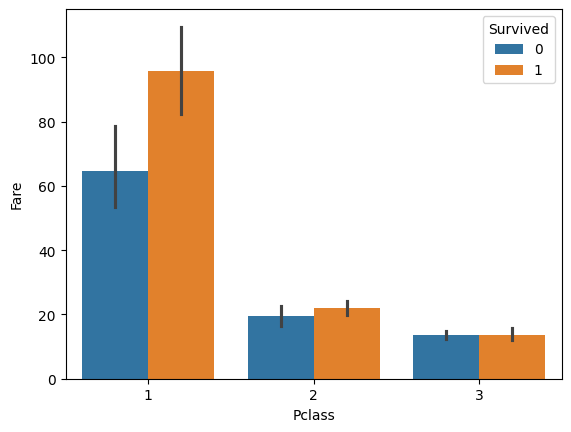

In [20]:
sns.barplot(x=df['Pclass'],y=df['Fare'],data=df,hue='Survived')
plt.show()

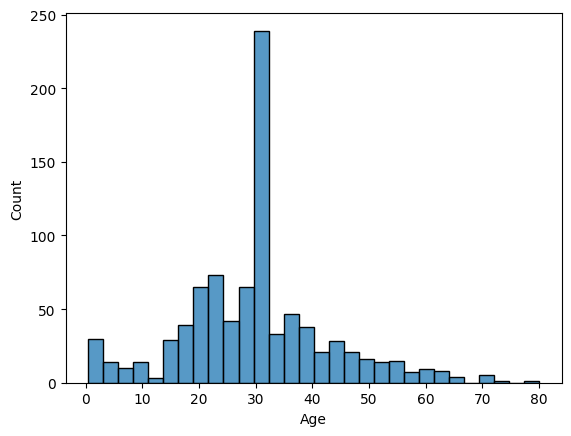

In [21]:
sns.histplot(x=df['Age'],data=df)
plt.show()

In [37]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

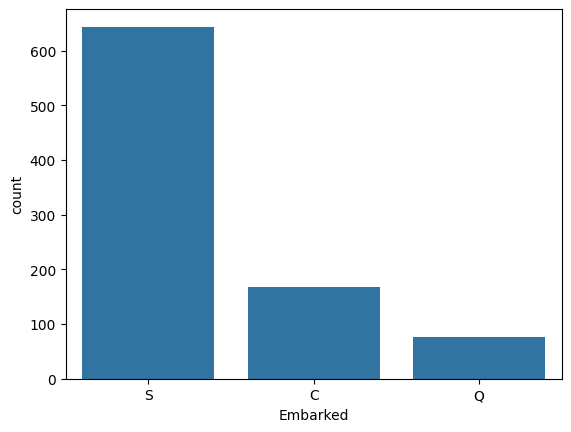

In [36]:
sns.countplot(x=df['Embarked'])
plt.show()

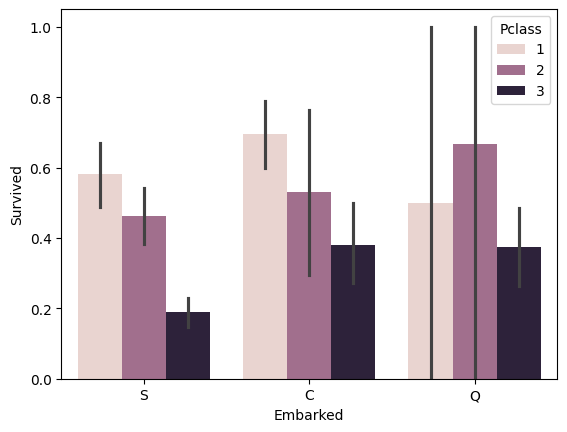

In [54]:
sns.barplot(x=df['Embarked'],y=df['Survived'],hue='Pclass',data=df)
plt.show()

<Axes: ylabel='Fare'>

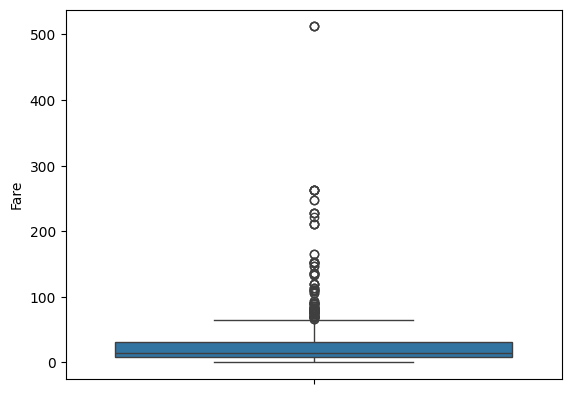

In [103]:
sns.boxplot(y=df['Fare'])

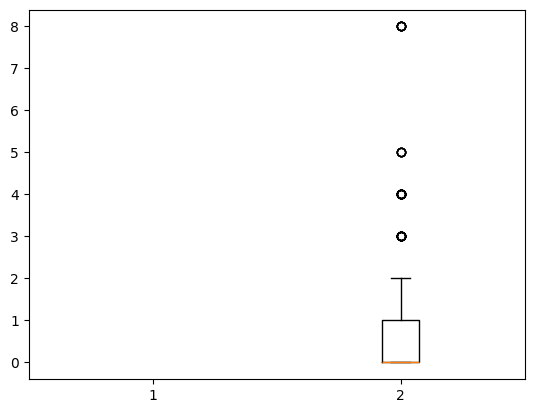

In [96]:
d =[df['Age'],df['SibSp']]
plt.boxplot(d)
plt.show()

<Axes: xlabel='Fare', ylabel='Density'>

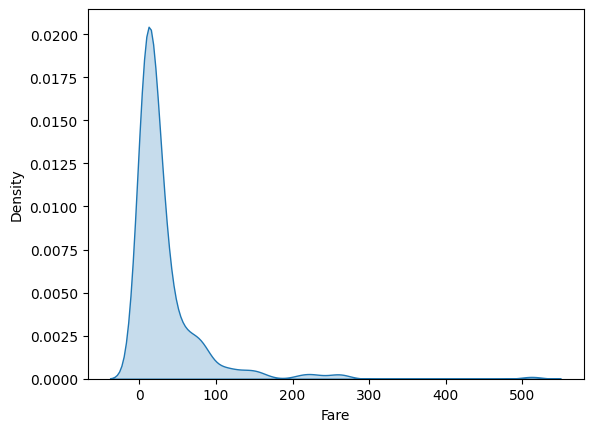

In [109]:

sns.kdeplot(data=df, x='Fare',fill=True)

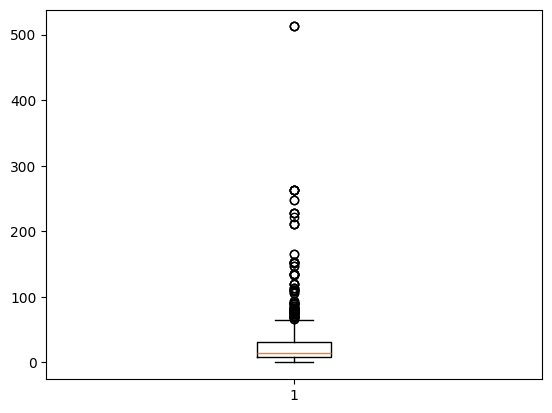

<Axes: ylabel='Age'>

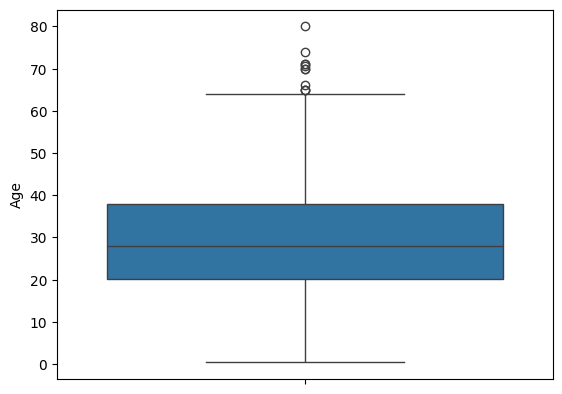

In [105]:
plt.boxplot(df['Fare'])
plt.show()
sns.boxplot(y=df['Age'],data=df)

In [91]:
df['Age']

Series([], Name: Age, dtype: float64)

In [84]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [85]:
df['Age'].value_counts()

Series([], Name: count, dtype: int64)

In [106]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)

iqr = q3 - q1

lf = q1 - 1.5 * iqr # Lower Fence
uf = q3 + 1.5 * iqr # Upper Fence

# --- Filtering (This line is CORRECTED) ---
# We keep values that are greater than the Lower Fence (lf)
# AND less than the Upper Fence (uf).
df_cleaned = df[(df['Age'] >= lf) & (df['Age'] <= uf)]

# Print the number of removed outliers for verification
rows_removed = len(df) - len(df_cleaned)
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_cleaned)}")
print(f"Outliers removed: {rows_removed}")

Original rows: 891
Cleaned rows: 703
Outliers removed: 188


<Axes: ylabel='Age'>

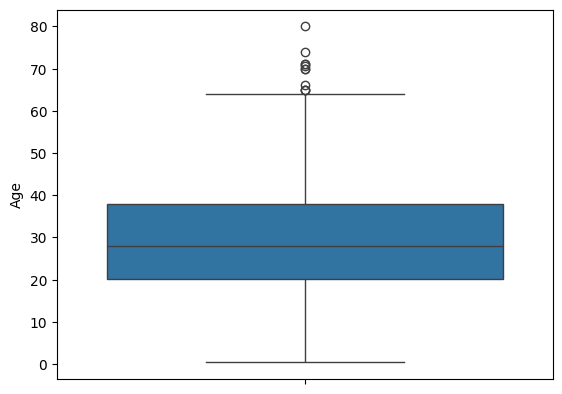

In [107]:
sns.boxplot(y=df['Age'],data=df)